In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# Simulation parameters

ENGY=[50, 200] # Energy range in Watt-hrs
LONG=[0, 100] # Longitude 10 km
LAT= [0, 100] # Latitude 10 km
ALT=[5, 20] # Altitude 0.5 km ie 500 m

#Inital reputation score is based on below resources
clock_speed_range=[50, 257] # Clock speed is from 5 to 15 MHz
memory_range=[2, 17] #RAM size is 2 to 16 GB
power_consumption_range = [500, 600]

# Total number of trails
TRIALS = 10
ITERATIONS = 1000

# Communication parameters
FREQUENCY = 2.4e9  # Frequency in Hz (2.4 GHz for WiFi)
BANDWIDTH = 20e6  # Bandwidth in Hz (20 MHz)
TRANSMISSION_POWER = 1  # Transmission power in Watts
NOISE_POWER = 1e-9  # Noise power in Watts (assumed)
SPEED_OF_LIGHT = 3e8  # Speed of light in meters per second
r=0.7 # Reputation weight
d=0.3 # Data Rate weight

def calculate_distance(uav1, uav2):
  """Calculates the Euclidean distance between two UAVs."""
  x1, y1, z1 = uav1.longitude, uav1.latitude, uav1.altitude
  x2, y2, z2 = uav2.longitude, uav2.latitude, uav2.altitude
  return np.sqrt((x1 - x2)**2 + (y1 - y2)**2 + (z1 - z2)**2)

def calculate_data_rate(distance):
  """Calculates the data rate between two UAVs given their distance."""
  path_loss = (SPEED_OF_LIGHT / (4 * np.pi * FREQUENCY * distance))**2
  snr = TRANSMISSION_POWER * path_loss / NOISE_POWER
  data_rate = BANDWIDTH * np.log2(1 + snr)
  return data_rate

# Function to update positions of UAVs
def update_uav_positions(uavs, long_range, lat_range, alt_range):
    for uav in uavs:
        uav.longitude = np.random.uniform(long_range[0], long_range[1])
        uav.latitude = np.random.uniform(lat_range[0], lat_range[1])
        uav.altitude = np.random.uniform(alt_range[0], alt_range[1])

# prompt: generate a class named uav, with the components of residual energy, memory, clock speed, logitude, latitude and altitude

class UAV:
  def __init__(self, residual_energy, memory, clock_speed, longitude, latitude, altitude, avg_power_consumption):
    self.residual_energy = residual_energy
    self.memory = memory
    self.clock_speed = clock_speed
    self.longitude = longitude
    self.latitude = latitude
    self.altitude = altitude
    self.avg_power_consumption = avg_power_consumption
    self.minimum_energy = residual_energy/10
    self.select_count = 0

class Task:
  def __init__(self, req_clock_speed, req_memory, max_latency, data_volume, instructions_per_unit_data):
    self.req_clock_speed = req_clock_speed
    self.req_memory = req_memory
    self.max_latency = max_latency
    self.data_volume = data_volume
    self.req_data_rate = data_volume / max_latency
    self.instructions_per_unit_data = instructions_per_unit_data
    self.total_instructions = instructions_per_unit_data*data_volume

energy_consumed_mean = np.zeros(TRIALS)
energy_consumed_mean_detto = np.zeros(TRIALS)
energy_consumed_mean_dpto = np.zeros(TRIALS)

a_arr_delay = 0
b_arr_delay = 0
c_arr_delay = 0

a_arr_energy = 0
b_arr_energy = 0
c_arr_energy = 0

num_tasks_comp = []

for iter in range(ITERATIONS):

    data_volume_range_array = [[100, 1000]]

    task_dfs = []
    task_dfs_detto = []
    task_dfs_dpto = []

    for data_i, data_volume_range in enumerate(data_volume_range_array): # data_i is the index of memory range (0, 1 or 2)
        # prompt: declare a variable num_uavs and create those many uavs with random parameters (i have LONG as the array of min and max ranges, LAT as the min and max ranges, and same the same thing for memory, clock_speed, and ALT for altitude)

        num_uavs = 20
        select_count = np.zeros(num_uavs)
        uavs = []
        for _ in range(num_uavs):
            residual_energy = np.random.uniform(ENGY[0], ENGY[1])
            memory = np.random.randint(memory_range[0], memory_range[1])
            clock_speed = np.random.randint(clock_speed_range[0], clock_speed_range[1])
            longitude = np.random.uniform(LONG[0], LONG[1])
            latitude = np.random.uniform(LAT[0], LAT[1])
            altitude = np.random.uniform(ALT[0], ALT[1])
            avg_power_consumption = np.random.uniform(power_consumption_range[0], power_consumption_range[1])
            uavs.append(UAV(residual_energy, memory, clock_speed, longitude, latitude, altitude, avg_power_consumption))

        # prompt: calculate initial reputation of uav as clock_speed*memory

        # Calculate initial reputation of UAVs
        uav_reputations = {}
        for i, uav in enumerate(uavs):
            uav_reputations[i] = uav.clock_speed * uav.memory

        energy_consumed_array = np.zeros(TRIALS)
        energy_consumed_array_detto = np.zeros(TRIALS)
        energy_consumed_array_dpto = np.zeros(TRIALS)

        import pandas as pd
        # Create a list of dictionaries, where each dictionary represents a UAV
        task_data = []
        task_data_detto = []
        task_data_dpto = []

        for trial in range(TRIALS):
            # prompt: calculate the data rate between every 2 uavs, i have only their positions. declare all the other variables required

            # Calculate data rates between all pairs of UAVs
            data_rates = np.zeros((num_uavs, num_uavs))
            for i in range(num_uavs):
                for j in range(i + 1, num_uavs):
                    distance = calculate_distance(uavs[i], uavs[j])
                    data_rate = calculate_data_rate(distance)
                    data_rates[i, j] = data_rate
                    data_rates[j, i] = data_rate  # Symmetric matrix

            # prompt: take a variable num_taks and generate the tasks with the random inputs

            # Ranges of task components
            req_clock_speed_range = [3, 4, 5, 6, 7, 3, 4, 5, 6, 7]
            req_memory_range = [6, 7, 8, 9, 10, 6, 7, 8, 9, 10]
            max_latency_range = [0.001, 0.01]
            data_volume_range = [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
            # instructions_per_unit_data_range = [1e6, 1.2e6, 1.4e6, 1.6e6, 1.8e6, 1e6, 1.2e6, 1.4e6, 1.6e6, 1.8e6]
            instructions_per_unit_data_range = [2e6, 2e6, 2e6, 2e6, 2e6, 2e6, 2e6, 2e6, 2e6, 2e6]

            num_tasks = 9
            tasks = []
            for t in range(num_tasks):
                # req_clock_speed = np.random.randint(req_clock_speed_range[0], req_clock_speed_range[1])
                # req_memory = np.random.randint(req_memory_range[0], req_memory_range[1])
                max_latency = np.random.uniform(max_latency_range[0], max_latency_range[1])  # Example latency range
                # # data_volume = np.random.uniform(data_volume_range[0], data_volume_range[1])  # Example data volume range
                # instructions_per_unit_data = np.random.randint(instructions_per_unit_data_range[0], instructions_per_unit_data_range[1])
                req_clock_speed = req_clock_speed_range[t]
                req_memory = req_memory_range[t]
                # max_latency = max_latency_range[t]
                data_volume = data_volume_range[t]
                instructions_per_unit_data = instructions_per_unit_data_range[t]
                tasks.append(Task(req_clock_speed, req_memory, max_latency, data_volume, instructions_per_unit_data))

            # prompt: now asisgn each task to a uav randomly and divide the uavs into two sets, (task uav which is alloted tasks and remaining as service uav)

            # Assign tasks randomly to UAVs
            task_assignments = {}
            available_uavs = list(range(num_uavs))
            for task_idx in range(num_tasks):
                if available_uavs:
                    selected_uav = random.choice(available_uavs)
                    task_assignments[task_idx] = selected_uav
                    available_uavs.remove(selected_uav)

            # Divide UAVs into task UAVs and service UAVs
            task_uavs = list(task_assignments.values())
            service_uavs = [uav_idx for uav_idx in range(num_uavs) if uav_idx not in task_uavs]

            # prompt: now check the eligibility of the service uavs for each task. to check the eligibility, we compare the memory and clock_speed requirements of the task with that of uav and also, we compare the req_data_rate of the task with the data rate between the uav and the task uav to which that task is associated with

            # Check eligibility of service UAVs for each task
            eligible_uavs = {}
            for task_idx, task_uav_idx in task_assignments.items():
                eligible_uavs[task_idx] = []
                for service_uav_idx in service_uavs:
                    service_uav = uavs[service_uav_idx]
                    task = tasks[task_idx]
                    # Check resource requirements and data rate
                    if (service_uav.memory >= task.req_memory and
                        service_uav.clock_speed >= task.req_clock_speed and
                        data_rates[service_uav_idx, task_uav_idx] >= 2*task.req_data_rate and
                        service_uav.residual_energy >= service_uav.minimum_energy):
                        eligible_uavs[task_idx].append(service_uav_idx)

            # prompt: get the reputation of only service uavs

            service_uav_reputations = {uav_idx: uav_reputations[uav_idx] for uav_idx in service_uavs}

            # prompt: for every task, calculate the trust between the uav associated with task and every other uav. trust = energy od the uav*(r*reputation + d*datarate between them)

            # Calculate trust values for each task
            trust_values = {}
            for task_idx, task_uav_idx in task_assignments.items():
                trust_values[task_idx] = {}
                for service_uav_idx in service_uavs:
                    service_uav = uavs[service_uav_idx]
                    reputation = service_uav_reputations[service_uav_idx]
                    data_rate = data_rates[task_uav_idx, service_uav_idx]
                    trust = service_uav.residual_energy * (r * reputation + d * data_rate)
                    trust_values[task_idx][service_uav_idx] = trust

            # prompt: for each task, select the service uav with maximum trust. note that once the service uav is selected, then do not consider it for the allocating another task

            # DPTO
            selected_service_uavs_dpto = {}
            for task_idx, eligible in eligible_uavs.items():
                if eligible:
                    selected_service_uavs_dpto[task_idx] = random.choice(eligible)

            # DeTTO
            selected_service_uavs_detto = {}
            already_selected_uavs_detto = set()

            for task_idx, task_uav_idx in task_assignments.items():
                task_detto = tasks[task_idx]
                task_uav_detto = uavs[task_uav_idx]
                min_cost_detto = float('inf')
                selected_uav_detto = None

                for service_uav_idx in service_uavs:
                    if service_uav_idx in already_selected_uavs_detto:
                        continue  # Skip already selected UAVs

                    service_uav_detto = uavs[service_uav_idx]
                    distance_detto = calculate_distance(task_uav_detto, service_uav_detto)
                    data_rate_detto = data_rates[task_uav_idx, service_uav_idx]

                    transmission_delay_detto = task_detto.data_volume * 1024 * 1024 / data_rate_detto
                    transmission_delay_detto = transmission_delay_detto / 3600  # Convert to hours
                    energy_consumption_detto = TRANSMISSION_POWER * transmission_delay_detto

                    total_cost = transmission_delay_detto + energy_consumption_detto

                    if total_cost < min_cost_detto:
                        min_cost_detto = total_cost
                        selected_uav_detto = service_uav_idx

                if selected_uav_detto is not None:
                    selected_service_uavs_detto[task_idx] = selected_uav_detto
                    already_selected_uavs_detto.add(selected_uav_detto)  # Mark UAV as selected

            # Select service UAV with maximum trust for each task (without repetition)
            selected_service_uavs = {}
            used_service_uavs = set()

            for task_idx, trust_dict in trust_values.items():
                # Sort eligible UAVs by trust in descending order
                sorted_uavs = sorted(trust_dict, key=trust_dict.get, reverse=True)

                for service_uav_idx in sorted_uavs:
                    if service_uav_idx not in used_service_uavs:
                        selected_service_uavs[task_idx] = service_uav_idx
                        used_service_uavs.add(service_uav_idx)
                        uavs[service_uav_idx].select_count += 1 # increment select count if uav is selected
                        break

            for task_idx, service_uav_idx in selected_service_uavs.items():
                select_count[service_uav_idx]+=1

            # prompt: calculate discounting factor for each uav where discounting_factor = (total_reputation/reputation_of_uav), then scale it down to 0 to 4 and then apply sigmoid to get the range between 0 to 1

            # Calculate total reputation
            total_reputation = sum(uav_reputations.values())

            # Calculate discounting factors
            discounting_factors = {}
            for uav_idx, reputation in uav_reputations.items():
                discounting_factors[uav_idx] = total_reputation / reputation

            # Scale down to 0 to 4 range
            scaled_factors = {}
            max_factor = max(discounting_factors.values())
            for uav_idx, factor in discounting_factors.items():
                scaled_factors[uav_idx] = (factor / max_factor) * 4

            # Apply sigmoid function
            sigmoid_factors = {}
            for uav_idx, factor in scaled_factors.items():
                sigmoid_factors[uav_idx] = 1 / (1 + np.exp(-factor))

            # prompt: calculate the award to be given by the task uav to service uav for completing a task. award = (1-discounting factor of service uav)/(1-discounting factor of service uav*discounting factor of task uav)

            # Calculate awards for selected service UAVs
            awards = {}
            for task_idx, service_uav_idx in selected_service_uavs.items():
                task_uav_idx = task_assignments[task_idx]
                discounting_factor_service = sigmoid_factors[service_uav_idx]
                discounting_factor_task = sigmoid_factors[task_uav_idx]
                award = (1 - discounting_factor_service) / (1 - discounting_factor_service * discounting_factor_task)
                awards[task_idx] = {
                    'service_uav': service_uav_idx,
                    'award': award
                }

            # prompt: now transfer the score, for transfering the score, the reputation of the task uav which gave the task should reduce by this fraction of award, i.e.  reputation of the task uav =  reputation of the task uav(1-award) and reputation of the service uav =  reputation of the service uav+  reputation of the task uav*award

            # Transfer scores based on awards
            for task_idx, award_info in awards.items():
                service_uav_idx = award_info['service_uav']
                task_uav_idx = task_assignments[task_idx]
                award = award_info['award']

                # Update reputations
                temp = uav_reputations[task_uav_idx]
                uav_reputations[task_uav_idx] *= (1 - award)
                uav_reputations[service_uav_idx] += temp * award

            # Update UAV positions after an iteration of the task
            update_uav_positions(uavs, LONG, LAT, ALT)

            # prompt: recalculate the residual energy of the service uav by reducing it by avg power * time of execution. and also reduct the energy of task uav the enrgy required to transmit the task, you have the task size and all the other parameters, it is upto you if any other variable that are needed to be declared.

            # Calculate execution times for tasks
            total_energy_consumed = 0
            execution_times = {}
            exec_times_arr = []
            transmission_times = {}
            service_energy_arr = []
            task_energy_arr = []
            trans_times_arr = []

            for task_idx, service_uav_idx in selected_service_uavs.items():
                task = tasks[task_idx]
                service_uav = uavs[service_uav_idx]
                execution_time = task.total_instructions / (service_uav.clock_speed*1e6)
                execution_time = execution_time / 3600
                execution_times[task_idx] = execution_time
                exec_times_arr.append(execution_time)

                # Reduce service UAV's residual energy
                energy_consumed_service = service_uav.avg_power_consumption * execution_time
                total_energy_consumed += energy_consumed_service
                service_energy_arr.append(energy_consumed_service)

                # Reduce task UAV's residual energy
                uavs[service_uav_idx].residual_energy -= energy_consumed_service

                # Calculate energy consumed by task UAV for transmission (simplified model)
                task_uav_idx = task_assignments[task_idx]
                distance = calculate_distance(uavs[task_uav_idx], uavs[service_uav_idx])
                transmission_time = (task.data_volume*1024*1024) / calculate_data_rate(distance)
                transmission_time = transmission_time / 3600
                transmission_times[task_idx] = transmission_time
                trans_times_arr.append(transmission_time)

                energy_consumed_task = TRANSMISSION_POWER * transmission_time
                total_energy_consumed += energy_consumed_task
                task_energy_arr.append(energy_consumed_task)
                uavs[task_uav_idx].residual_energy -= energy_consumed_task

            #DeTTo
            # Calculate execution times for tasks
            total_energy_consumed_detto = 0
            execution_times_detto = {}
            exec_times_arr_detto = []
            transmission_times_detto = {}
            service_energy_arr_detto = []
            task_energy_arr_detto = []
            trans_times_arr_detto = []

            for task_idx, service_uav_idx in selected_service_uavs_detto.items():
                task_detto = tasks[task_idx]
                service_uav_detto = uavs[service_uav_idx]
                execution_time_detto = task_detto.total_instructions / (service_uav_detto.clock_speed*1e6)
                execution_time_detto = execution_time_detto / 3600
                execution_times_detto[task_idx] = execution_time_detto
                exec_times_arr_detto.append(execution_time_detto)

                # Reduce service UAV's residual energy
                energy_consumed_service_detto = service_uav_detto.avg_power_consumption * execution_time_detto
                total_energy_consumed_detto += energy_consumed_service_detto
                service_energy_arr_detto.append(energy_consumed_service_detto)

                # Reduce task UAV's residual energy
                uavs[service_uav_idx].residual_energy -= energy_consumed_service_detto

                # Calculate energy consumed by task UAV for transmission (simplified model)
                task_uav_idx_detto = task_assignments[task_idx]
                distance_detto = calculate_distance(uavs[task_uav_idx_detto], uavs[service_uav_idx])
                transmission_time_detto = (task_detto.data_volume*1024*1024) / calculate_data_rate(distance_detto)
                transmission_time_detto = transmission_time_detto / 3600
                transmission_times_detto[task_idx] = transmission_time_detto
                trans_times_arr_detto.append(transmission_time_detto)

                energy_consumed_task_detto = TRANSMISSION_POWER * transmission_time_detto
                total_energy_consumed_detto += energy_consumed_task_detto
                task_energy_arr_detto.append(energy_consumed_task_detto)
                uavs[task_uav_idx_detto].residual_energy -= energy_consumed_task_detto

            #DPTO
            # Calculate execution times for tasks
            total_energy_consumed_dpto = 0
            execution_times_dpto = {}
            exec_times_arr_dpto = []
            transmission_times_dpto = {}
            service_energy_arr_dpto = []
            task_energy_arr_dpto = []
            trans_times_arr_dpto = []

            for task_idx, service_uav_idx in selected_service_uavs_dpto.items():
                task_dpto = tasks[task_idx]
                service_uav_dpto = uavs[service_uav_idx]
                execution_time_dpto = task_dpto.total_instructions / (service_uav_dpto.clock_speed*1e6)
                execution_time_dpto = execution_time_dpto / 3600
                execution_times_dpto[task_idx] = execution_time_dpto
                exec_times_arr_dpto.append(execution_time_dpto)

                # Reduce service UAV's residual energy
                energy_consumed_service_dpto = service_uav_dpto.avg_power_consumption * execution_time_dpto
                total_energy_consumed_dpto += energy_consumed_service_dpto
                service_energy_arr_dpto.append(energy_consumed_service_dpto)

                # Reduce task UAV's residual energy
                uavs[service_uav_idx].residual_energy -= energy_consumed_service_dpto

                # Calculate energy consumed by task UAV for transmission (simplified model)
                task_uav_idx_dpto = task_assignments[task_idx]
                distance_dpto = calculate_distance(uavs[task_uav_idx_dpto], uavs[service_uav_idx])
                transmission_time_dpto = (task_dpto.data_volume*1024*1024) / calculate_data_rate(distance_dpto)
                transmission_time_dpto = transmission_time_dpto / 3600
                transmission_times_dpto[task_idx] = transmission_time_dpto
                trans_times_arr_dpto.append(transmission_time_dpto)

                energy_consumed_task_dpto = TRANSMISSION_POWER * transmission_time_dpto
                total_energy_consumed_dpto += energy_consumed_task_dpto
                task_energy_arr_dpto.append(energy_consumed_task_dpto)
                uavs[task_uav_idx_dpto].residual_energy -= energy_consumed_task_dpto

            # print("Total energy consumed: ", total_energy_consumed)
            energy_consumed_array[trial] = total_energy_consumed
            energy_consumed_array_detto[trial] = total_energy_consumed_detto
            energy_consumed_array_dpto[trial] = total_energy_consumed_dpto

            # prompt: create a dataframe named uav for all the uavs and the components of uav class as the columns
            for i in range (len(trans_times_arr)):
                task_data.append({
                    # 'Task ID': (i+1)*(trial+1),
                    'Task ID': i,
                    'Trial': trial,
                    'Execution Time': exec_times_arr[i],
                    'Transmission Time': trans_times_arr[i],
                    'Task Energy': task_energy_arr[i],
                    'Service Energy': service_energy_arr[i]
                })

            for i in range (len(trans_times_arr_detto)):
                task_data_detto.append({
                    # 'Task ID': (i+1)*(trial+1),
                    'Task ID': i,
                    'Trial': trial,
                    'Execution Time': exec_times_arr_detto[i],
                    'Transmission Time': trans_times_arr_detto[i],
                    'Task Energy': task_energy_arr_detto[i],
                    'Service Energy': service_energy_arr_detto[i]
                })

            for i in range (len(trans_times_arr_dpto)):
                task_data_dpto.append({
                    # 'Task ID': (i+1)*(trial+1),
                    'Task ID': i,
                    'Trial': trial,
                    'Execution Time': exec_times_arr_dpto[i],
                    'Transmission Time': trans_times_arr_dpto[i],
                    'Task Energy': task_energy_arr_dpto[i],
                    'Service Energy': service_energy_arr_dpto[i]
                })
        # print(energy_consumed_array)
        energy_consumed_mean += energy_consumed_array
        energy_consumed_mean_detto += energy_consumed_array_detto
        energy_consumed_mean_dpto += energy_consumed_array_dpto

        # Create the DataFrame from the list of dictionaries
        task_df = pd.DataFrame(task_data)
        task_df.to_csv(f'task_data_{data_i}_trust.csv', index=False)

        task_df_detto = pd.DataFrame(task_data_detto)
        task_df_detto.to_csv(f'task_data_{data_i}_detto.csv', index=False)

        task_df_dpto = pd.DataFrame(task_data_dpto)
        task_df_dpto.to_csv(f'task_data_{data_i}_dpto.csv', index=False)

        # Display the DataFrame
        # print(task_dfs)
        task_dfs.append(task_df)
        task_dfs_detto.append(task_df_detto)
        task_dfs_dpto.append(task_df_dpto)

    # print(len(task_dfs), len(task_dfs_detto), len(task_dfs_dpto))

    task_data_0_detto = pd.read_csv("task_data_0_detto.csv")
    task_data_0_dpto = pd.read_csv("task_data_0_dpto.csv")
    task_data_0_trust = pd.read_csv("task_data_0_trust.csv")

    mean_detto_transmission_energy = task_data_0_detto.groupby('Task ID')['Task Energy'].mean()
    mean_detto_execution_energy = task_data_0_detto.groupby('Task ID')['Service Energy'].mean()

    mean_dpto_transmission_energy = task_data_0_dpto.groupby('Task ID')['Task Energy'].mean()
    mean_dpto_execution_energy = task_data_0_dpto.groupby('Task ID')['Service Energy'].mean()

    mean_trust_transmission_energy = task_data_0_trust.groupby('Task ID')['Task Energy'].mean()
    mean_trust_execution_energy = task_data_0_trust.groupby('Task ID')['Service Energy'].mean()

    a_arr_energy += np.mean(mean_detto_execution_energy)
    b_arr_energy += np.mean(mean_dpto_execution_energy)
    c_arr_energy += np.mean(mean_trust_execution_energy)

    mean_detto_transmission_delay = task_data_0_detto.groupby('Task ID')['Transmission Time'].mean()
    mean_detto_execution_delay = task_data_0_detto.groupby('Task ID')['Execution Time'].mean()

    mean_dpto_transmission_delay = task_data_0_dpto.groupby('Task ID')['Transmission Time'].mean()
    mean_dpto_execution_delay = task_data_0_dpto.groupby('Task ID')['Execution Time'].mean()

    mean_trust_transmission_delay = task_data_0_trust.groupby('Task ID')['Transmission Time'].mean()
    mean_trust_execution_delay = task_data_0_trust.groupby('Task ID')['Execution Time'].mean()

    a_arr_delay += np.mean(mean_detto_execution_delay)
    b_arr_delay += np.mean(mean_dpto_execution_delay)
    c_arr_delay += np.mean(mean_trust_execution_delay)
    # print(len(task_data_0_detto))

print(a_arr_delay*3600/1000, b_arr_delay*3600/1000, c_arr_delay*3600/1000)

15.833182295509008 15.734145796162766 15.402585509064531


In [ ]:
print(a_arr_energy/1000, b_arr_energy/1000, c_arr_energy/1000)

0.8201526014247367 0.8191609139358621 0.814298337620267


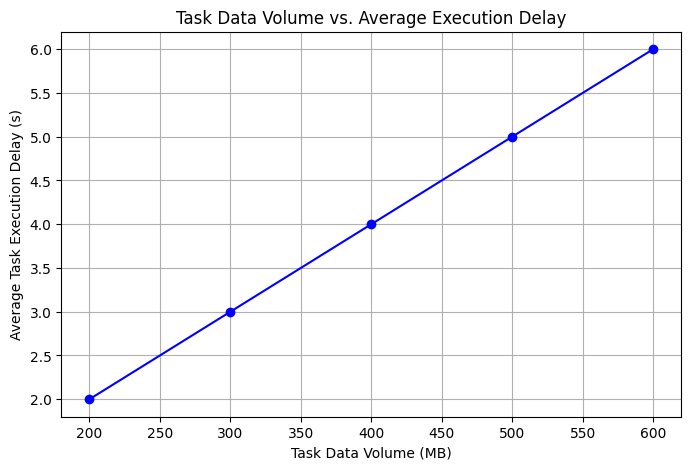

Average Execution Delay per Task Size:
Task Size 200 MB: 2.00 seconds
Task Size 300 MB: 3.00 seconds
Task Size 400 MB: 4.00 seconds
Task Size 500 MB: 5.00 seconds
Task Size 600 MB: 6.00 seconds


In [29]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Simulation Parameters
NUM_FOG_NODES = 5  # Number of fog nodes
TASK_ARRIVAL_RATE = 2  # Tasks per second
SIMULATION_TIME = 100  # Total simulation time in seconds
QUEUE_THRESHOLD = 3  # Max queue length before offloading
TASK_SIZES = [200, 300, 400, 500, 600]  # Task sizes in MB

# Processing Speeds
LOCAL_PROCESS_TIME_PER_MB = 10  # Local execution time (ms per MB)
FOG_PROCESS_TIME_PER_MB = 10  # Fog execution time (ms per MB)

# Communication Parameters
FREQUENCY = 2.4e9  # Frequency in Hz (2.4 GHz)
BANDWIDTH = 20e6  # Bandwidth in Hz (20 MHz)
TRANSMISSION_POWER = 1  # Transmission power in Watts
NOISE_POWER = 1e-9  # Noise power in Watts
SPEED_OF_LIGHT = 3e8  # Speed of light in meters per second

# Compute Transmission Rate using Shannon Capacity Formula
transmission_rate = BANDWIDTH * np.log2(1 + (TRANSMISSION_POWER / NOISE_POWER))

# Initialize Fog Nodes with Queues
fog_nodes = [{"queue": [], "busy_until": 0} for _ in range(NUM_FOG_NODES)]

# Task Offloading Simulation
task_delays = {size: [] for size in TASK_SIZES}  # Store delays per task size
fog_utilization = [0] * NUM_FOG_NODES
task_count = 0

# Function to find the best fog node (least busy)
def find_best_fog_node():
    return min(fog_nodes, key=lambda node: len(node["queue"]))

for t in range(SIMULATION_TIME):
    # Task arrival (Poisson process)
    if random.random() < TASK_ARRIVAL_RATE / 10:
        task_count += 1
        task_size = random.choice(TASK_SIZES)  # Assign a random task size
        task = {"arrival_time": t, "size": task_size}

        # Compute Transmission Time (Offloading Delay)
        transmission_time = task_size / transmission_rate  # in seconds

        # Find best fog node
        best_fog = find_best_fog_node()

        if len(best_fog["queue"]) < QUEUE_THRESHOLD:  # Offload if queue is manageable
            best_fog["queue"].append(task)
            best_fog["busy_until"] += (task_size * FOG_PROCESS_TIME_PER_MB) / 1000  # Convert ms to sec
            fog_utilization[fog_nodes.index(best_fog)] += 1
            task["completion_time"] = t + transmission_time + (task_size * FOG_PROCESS_TIME_PER_MB) / 1000
        else:  # Process locally if queue is long
            task["completion_time"] = t + (task_size * LOCAL_PROCESS_TIME_PER_MB) / 1000

        # Log task delay
        task_delay = task["completion_time"] - task["arrival_time"]
        task_delays[task_size].append(task_delay)

# Compute Average Delay for Each Task Size
avg_delays = {size: np.mean(delays) if delays else 0 for size, delays in task_delays.items()}

# Plot Task Size vs. Average Delay
plt.figure(figsize=(8, 5))
plt.plot(list(avg_delays.keys()), list(avg_delays.values()), marker='o', linestyle='-', color='b')
plt.xlabel("Task Data Volume (MB)")
plt.ylabel("Average Task Execution Delay (s)")
plt.title("Task Data Volume vs. Average Execution Delay")
plt.grid(True)

# Show plot
plt.show()

# Print Results
print("Average Execution Delay per Task Size:")
for size, delay in avg_delays.items():
    print(f"Task Size {size} MB: {delay:.2f} seconds")
